# 04. Predicting No Future Purchase

**Project:** Customer Churn Prediction & Lifetime Value.

**Source material:** this notebook's own techniques aren't drawn from the source
articles -- Logistic Regression and Gradient Boosting are standard choices for a binary
churn label, not something the CLV/churn series prescribes. What *is* article-driven is
a decision about what **not** to do: Fabio Oliveira's "Your Churn Threshold Is a
Pricing Decision" (the article notebook 5 is built around) warns that SMOTE can distort
a model's predicted probabilities badly enough to break the closed-form threshold
formula his article relies on. Since this whole project's downstream threshold work
depends on that formula being checkable, that warning is tested directly below rather
than just taken on faith.

**This notebook covers:**
1. Fitting two candidate churn models -- Logistic Regression and Gradient Boosting --
   on train customers only, and checking whether Oliveira's SMOTE warning holds here
2. Validation discrimination and calibration: Brier score, ROC AUC, PR AUC, reliability
   curves
3. What each model actually learned (coefficients / feature importances), read as
   associations, not causal claims
4. Exporting held-out probabilities **without** picking a threshold -- that's notebook
   5's job, once illustrative costs are on the table

**Question:** among the 1,926 customers with an established calibration-period buying
pattern, who places zero valid orders from September through November 2011? "Churn"
here is a fixed operational label for this specific window in a non-contractual retail
business -- not a claim that a flagged customer has permanently left. Both models use
only the eight calibration-derived features from notebook 3; neither sees full-history
RFM, the outcome label, or any holdout-period transaction.

### Import necessary libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    brier_score_loss, roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, classification_report
)
from imblearn.over_sampling import SMOTE
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, precision_recall_curve

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

FEATURE_COLS = ["orders_cal", "revenue_cal", "mean_order_value_cal", "recency_days_cal",
                "tenure_days_cal", "purchase_span_days_cal", "orders_per_30_days_cal",
                "recency_to_tenure_cal"]

### Load & Inspect data

In [2]:
# Resolve repository paths whether Jupyter is launched from the
# repository root or from the notebooks directory.
REPO_ROOT = Path.cwd()

if not (REPO_ROOT / 'data').exists():
    REPO_ROOT = REPO_ROOT.parent

RAW_DATA = REPO_ROOT / 'data' / 'raw'
PROCESSED_DATA = REPO_ROOT / 'data' / 'processed'

In [3]:
features = pd.read_parquet(PROCESSED_DATA / "retail_features.parquet")
manifest = pd.read_parquet(PROCESSED_DATA / "retail_population_manifest.parquet")
rfm = pd.read_parquet(PROCESSED_DATA / "retail_rfm.parquet")[["CustomerID", "segment"]]

features = features.merge(rfm, on="CustomerID", validate="one_to_one")
assert set(features["CustomerID"]) == set(manifest.loc[manifest["eligible_repeat"], "CustomerID"])
assert features[FEATURE_COLS].notna().all().all()

print(features.groupby("split").size().rename("n").to_string())
print("\nDevelopment churn rates:", features.loc[features["split"].ne("test")].groupby("split")["churned"].mean().to_dict())

split
test           386
train         1155
validation     385

Development churn rates: {'train': 0.30043290043290044, 'validation': 0.2987012987012987}


## 1. Fit two candidate models on train customers only

Logistic Regression is the transparent baseline -- a linear decision boundary, easy to
audit coefficient by coefficient. Gradient Boosting allows nonlinear interactions the
linear model structurally can't capture. Both see exactly the same eight features and
exactly the same train customers; neither is tuned against validation before this
point.

In [4]:
X = features[FEATURE_COLS]
y = features["churned"].astype(int)
train_mask = features["split"].eq("train")

models = {
    "lr": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    "gbc": GradientBoostingClassifier(n_estimators=100, max_depth=2, random_state=42),
}
for name, model in models.items():
    model.fit(X.loc[train_mask], y.loc[train_mask])
    features[f"proba_{name}"] = model.predict_proba(X)[:, 1]
    assert features[f"proba_{name}"].between(0, 1).all()

print(f"Both models trained on {train_mask.sum():,} train customers")

Both models trained on 1,155 train customers


### Checking Oliveira's SMOTE warning directly, rather than assuming it applies

Churn here sits at roughly 30/70, mild enough that reweighting the classes is a real
temptation. Two common ways to do it -- `class_weight="balanced"` and SMOTE
oversampling -- are fit here purely as a diagnostic, on the same train split, and
compared against the baseline LR above on validation. The prediction is that both will
distort the model's predicted *probabilities* without necessarily hurting how well it
*ranks* customers, which is exactly the failure mode Oliveira traces to a broken
threshold formula in his own article: a ranking metric wouldn't catch it, but a
threshold picked from the resulting probabilities would be picked on a lie. Neither
variant is used anywhere past this check -- the notebook continues with the plain
baseline models fit above.

In [5]:
diagnostic_val_mask = features["split"].eq("validation")
X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[diagnostic_val_mask], y.loc[diagnostic_val_mask]

reweight_variants = {"lr_baseline": features.loc[diagnostic_val_mask, "proba_lr"]}

balanced_lr = make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
balanced_lr.fit(X_train, y_train)
reweight_variants["lr_class_weight_balanced"] = pd.Series(balanced_lr.predict_proba(X_val)[:, 1], index=X_val.index)

scaler = StandardScaler().fit(X_train)
X_res, y_res = SMOTE(random_state=42).fit_resample(scaler.transform(X_train), y_train)
smote_lr = LogisticRegression(max_iter=1000, random_state=42)
smote_lr.fit(X_res, y_res)
reweight_variants["lr_smote"] = pd.Series(smote_lr.predict_proba(scaler.transform(X_val))[:, 1], index=X_val.index)

print(f"Actual validation churn rate: {y_val.mean():.4f}\n")
for name, proba in reweight_variants.items():
    print(f"{name:26s} mean_pred={proba.mean():.4f}  brier={brier_score_loss(y_val, proba):.4f}  "
          f"roc_auc={roc_auc_score(y_val, proba):.4f}  pr_auc={average_precision_score(y_val, proba):.4f}")

Actual validation churn rate: 0.2987

lr_baseline                mean_pred=0.2930  brier=0.1811  roc_auc=0.7294  pr_auc=0.5236
lr_class_weight_balanced   mean_pred=0.4579  brier=0.2087  roc_auc=0.7312  pr_auc=0.5265
lr_smote                   mean_pred=0.4522  brier=0.2075  roc_auc=0.7297  pr_auc=0.5287


**The warning holds up.** Both reweighted variants push the mean predicted
probability to roughly 0.45 -- far above the 29.9% actual rate the plain baseline
tracks closely -- while Brier score worsens from 0.1811 to around 0.208. ROC AUC and PR
AUC barely move, in this case even edging up slightly, which is exactly the point:
ranking quality survives reweighting almost untouched, so a ranking-only check would
have missed the problem entirely. This is the same mechanism Oliveira's article
describes for why SMOTE broke his formula-vs-sweep comparison, now confirmed on this
project's own data rather than taken on the article's word. It's also the direct
justification for skipping both techniques in every model fit through the rest of this
project.

## 2. Validation performance

Three metrics, each answering a different question: **Brier score** (lower is better)
penalizes both miscalibration and poor discrimination together; **ROC AUC** asks how
well the model ranks churners above non-churners regardless of threshold; **PR AUC** is
the more informative ranking metric when, as here, the positive class isn't the
majority.

In [6]:
validation = features.loc[features["split"].eq("validation")]
metric_rows = []
for name in models:
    pred = validation[f"proba_{name}"]
    metric_rows.append({
        "model": name, "n": len(validation), "actual_rate": validation["churned"].mean(),
        "mean_prediction": pred.mean(), "brier": brier_score_loss(validation["churned"], pred),
        "roc_auc": roc_auc_score(validation["churned"], pred),
        "pr_auc": average_precision_score(validation["churned"], pred)})
pd.DataFrame(metric_rows)

,model,n,actual_rate,mean_prediction,brier,roc_auc,pr_auc
0,lr,385,0.298701,0.293016,0.181086,0.729404,0.523613
1,gbc,385,0.298701,0.296379,0.175532,0.749533,0.556646


**Validation result (n = 385; churn rate 29.9%).** GBC edges out LR on every
metric: Brier **0.1755** vs **0.1811**, ROC AUC **0.7495** vs **0.7294**, PR AUC
**0.5566** vs **0.5236**. Both models' mean predictions land close to the 29.9% observed
rate -- a necessary check, but not by itself proof of calibration; the reliability plot
below looks at whether that holds bin by bin, not just on average.


LR — validation, threshold 0.50
                precision    recall  f1-score   support

  Churned (=1)       0.73      0.92      0.82       270
Purchased (=0)       0.52      0.20      0.29       115

      accuracy                           0.71       385
     macro avg       0.63      0.56      0.55       385
  weighted avg       0.67      0.71      0.66       385


GBC — validation, threshold 0.50
                precision    recall  f1-score   support

  Churned (=1)       0.75      0.91      0.82       270
Purchased (=0)       0.58      0.30      0.40       115

      accuracy                           0.73       385
     macro avg       0.67      0.61      0.61       385
  weighted avg       0.70      0.73      0.70       385



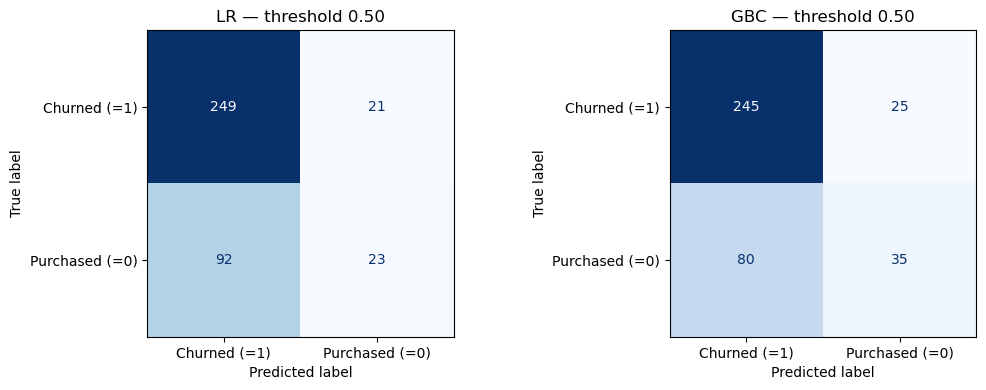

In [7]:
validation = features.loc[features["split"].eq("validation")]
y_true = validation["churned"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, name in zip(axes, ["lr", "gbc"]):
    threshold = 0.50
    y_pred = validation[f"proba_{name}"].ge(threshold).astype(int)

    print(f"\n{name.upper()} — validation, threshold {threshold:.2f}")
    print(classification_report(
        y_true, y_pred,
        labels=[0, 1],
        target_names=["Churned (=1)", "Purchased (=0)"],
        zero_division=0,
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        labels=[0, 1],
        display_labels=["Churned (=1)", "Purchased (=0)"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"{name.upper()} — threshold {threshold:.2f}")

fig.tight_layout()
plt.show()

**Reading the matrix:** rows are what actually happened; columns are what was predicted. The upper-right cell is customers flagged as churners who purchased (false positives); the lower-left is churners the rule missed (false negatives).

At 0.50, GBC finds **35 of 115 churners (30% recall)** versus LR’s **23 of 115 (20%)**, while flagging four more customers who actually purchased. That makes GBC the stronger of these two 0.50 classification summaries.  
These reports are diagnostics at 0.50, not performance of the final policy.

In [8]:
segment_breakdown = (validation.groupby("segment").agg(
    n=("CustomerID", "size"), actual_churn=("churned", "mean"),
    mean_proba_lr=("proba_lr", "mean"), mean_proba_gbc=("proba_gbc", "mean"))
    .sort_values("n", ascending=False))
segment_breakdown

,n,actual_churn,mean_proba_lr,mean_proba_gbc
segment,,,,
Loyal Customers,82,0.134146,0.153928,0.136513
Lost / Lowest Priority,68,0.529412,0.511316,0.528133
"Recent, Low Engagement",65,0.338462,0.265836,0.353927
Needs Attention,47,0.382979,0.357457,0.381411
High-Value Infrequent Buyers,32,0.437500,0.457760,0.355421
At Risk,29,0.344828,0.338897,0.333055
Potential Loyalists,27,0.074074,0.155754,0.104454
Champions,26,0.000000,0.031554,0.039034
Churn Risk (high value),9,0.222222,0.204179,0.133349


Segment-level churn rates here are descriptive only, and several segments are
thin enough on validation (single digits for Churn Risk (high value)) that any one row
is noisy. One row stands out regardless of sample size: **Champions show a 0.0% actual
churn rate on validation**, and both models correctly predict a low probability for
them (3-4%). That's a plausible pattern on its own -- a customer who's recent, frequent,
and high-spending is a genuinely safe bet not to have vanished in the next 91 days --
but a *literal* zero is also exactly the kind of result worth double-checking rather
than taking at face value. `segment` was never a model feature, but it's worth watching
whether segment-level churn rates like this one turn out to be near-definitional rather
than predictive -- notebook 6 returns to that question directly once the full pipeline
is assembled.

### What drives the fitted models?

Standardized LR coefficients and GBC's feature importances describe **associations
learned by these specific trained models** -- not the causal effect of changing a
customer's behavior, and not immune to two correlated features quietly sharing credit
for the same signal.

In [9]:
importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "lr_scaled_coefficient": models["lr"].named_steps["logisticregression"].coef_[0],
    "gbc_importance": models["gbc"].feature_importances_})
importance.sort_values("gbc_importance", ascending=False).round(3)

,feature,lr_scaled_coefficient,gbc_importance
1,revenue_cal,-1.413,0.290
7,recency_to_tenure_cal,0.601,0.227
6,orders_per_30_days_cal,-0.469,0.129
2,mean_order_value_cal,0.221,0.123
0,orders_cal,-0.754,0.097
3,recency_days_cal,-0.129,0.060
4,tenure_days_cal,0.014,0.052
5,purchase_span_days_cal,0.092,0.022


`revenue_cal` and `recency_to_tenure_cal` carry the most GBC importance (0.290 and
0.224), and both are also among LR's largest-magnitude coefficients -- a customer who
spent little and whose last purchase sits far into their own tenure, relative to how
long they've been active, looks more likely to have drifted off, and both models agree
on that. `orders_cal` and `orders_per_30_days_cal` matter to both as well, in the
expected direction (more orders, less churn risk). `purchase_span_days_cal` is the
weakest signal for either model -- knowing how spread out someone's past orders were
adds little once order count and recency are already in the mix.

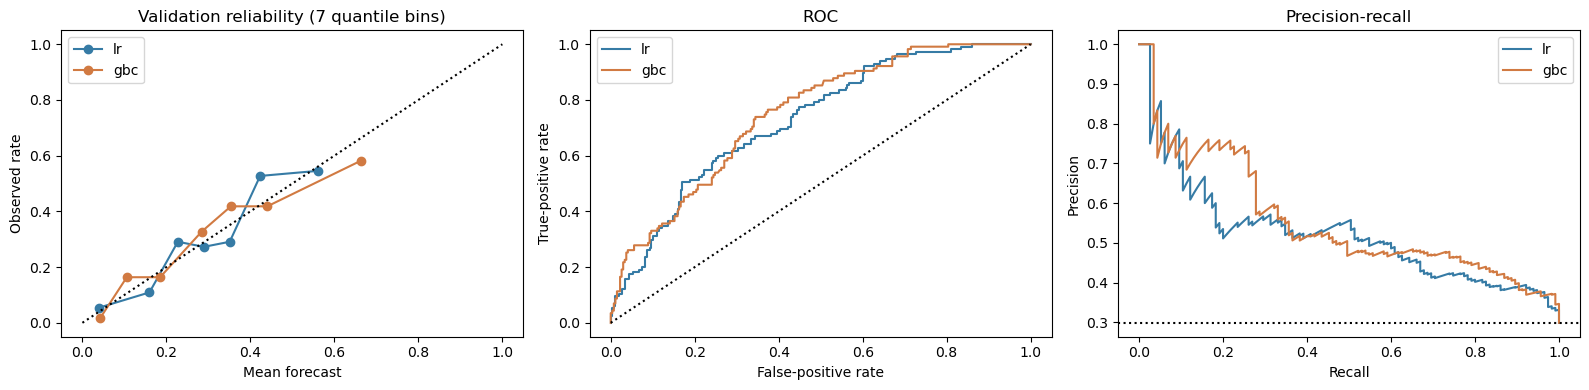

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name, color in [("lr", "#367ba5"), ("gbc", "#d17a42")]:
    proba = validation[f"proba_{name}"]
    observed, predicted = calibration_curve(validation["churned"], proba, n_bins=7, strategy="quantile")
    axes[0].plot(predicted, observed, "o-", label=name, color=color)
    fpr, tpr, _ = roc_curve(validation["churned"], proba)
    axes[1].plot(fpr, tpr, label=name, color=color)
    precision, recall, _ = precision_recall_curve(validation["churned"], proba)
    axes[2].plot(recall, precision, label=name, color=color)

axes[0].plot([0, 1], [0, 1], ":", color="black")
axes[0].set(title="Validation reliability (7 quantile bins)", xlabel="Mean forecast", ylabel="Observed rate")
axes[1].plot([0, 1], [0, 1], ":", color="black")
axes[1].set(title="ROC", xlabel="False-positive rate", ylabel="True-positive rate")
axes[2].axhline(validation["churned"].mean(), linestyle=":", color="black")
axes[2].set(title="Precision-recall", xlabel="Recall", ylabel="Precision")
for ax in axes: ax.legend()
fig.tight_layout(); plt.show(); plt.close(fig)

**Reading the validation curves.** GBC sits modestly above LR across parts of the
ROC and precision-recall ranges, consistent with its slightly better AUC and PR AUC.
Both reliability lines stay fairly close to the diagonal across seven quantile bins,
with the most visible deviation in the middle predicted-risk range. None of this fixes
a classification threshold -- the default 0.5 cutpoint shown implicitly by "50/50" on
these axes is a descriptive convention, not the decision optimum once unequal
illustrative costs enter the picture in notebook 5.

## 3. Export held-out probabilities without selecting a threshold

In [11]:
export = features.loc[~train_mask, ["CustomerID", "split", "churned", "segment", "proba_lr", "proba_gbc"]]
assert export["CustomerID"].is_unique
assert sorted(export["split"].unique()) == ["test", "validation"]
export.to_parquet(PROCESSED_DATA / "retail_churn_probabilities.parquet", index=False)
print(f"Saved {len(export):,} held-out probability rows")

Saved 771 held-out probability rows


### Summary

- Two calibration-feature-only models, trained on the same 1,155 train customers:
  **GBC modestly outperforms LR** on every validation metric (Brier 0.1755 vs 0.1811,
  ROC AUC 0.7495 vs 0.7294, PR AUC 0.5566 vs 0.5236).
- `revenue_cal` and `recency_to_tenure_cal` carry the most weight in both models,
  with order-frequency features close behind; GBC additionally picks up nonlinear
  signal from order value and tenure that the linear model can't represent.
- Reliability curves stay reasonably close to the diagonal on validation, but that's a
  diagnostic check, not a promise the models are well-calibrated at whatever low
  action-threshold notebook 5 eventually selects.
- **No threshold is chosen here.** Held-out probabilities for validation and test are
  exported as-is; picking a cutpoint is an economic decision that depends on
  illustrative action costs, made explicitly in the next notebook.

**Next:** `05_Threshold_Economics.ipynb` -- attach illustrative segment action prices
and false-negative costs, select a model and threshold on validation only, then run one
locked evaluation on test.